<!-- launch-badges -->
<a href="https://colab.research.google.com/github/laban254/ml-for-infrastructure/blob/main/04_deep_learning/keras/Basic_Keras_MNIST_Practice.ipynb" target="_blank"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
&nbsp;
<a href="https://mybinder.org/v2/gh/laban254/ml-for-infrastructure/main?urlpath=lab/tree/04_deep_learning/keras/Basic_Keras_MNIST_Practice.ipynb" target="_blank"><img src="https://mybinder.org/badge_logo.svg" alt="Open in Binder"/></a>

> ▶️ **Run this notebook live** — no install needed. Click a badge above to open it in a free cloud runtime.

<a href="https://colab.research.google.com/github/Laban254/data-science-and-ml-exercises/blob/main/keras/Basic_Keras_MNIST_Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

imports

In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt


2026-06-17 16:07:11.823261: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Load and Preprocess the MNIST Dataset:

In [2]:
# Load the MNIST dataset
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

# Normalize the pixel values to be between 0 and 1
train_images = train_images / 255.0
test_images = test_images / 255.0

# Flatten the 28x28 images into 1D vectors of size 784
train_images = train_images.reshape((train_images.shape[0], 28 * 28))
test_images = test_images.reshape((test_images.shape[0], 28 * 28))


       0/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step

   16384/11490434 ━━━━━━━━━━━━━━━━━━━━ 1:46 9us/step

   32768/11490434 ━━━━━━━━━━━━━━━━━━━━ 1:21 7us/step

   49152/11490434 ━━━━━━━━━━━━━━━━━━━━ 1:34 8us/step

   65536/11490434 ━━━━━━━━━━━━━━━━━━━━ 1:23 7us/step

...

 9125888/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

 9912320/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

10297344/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

11370496/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Build the Model:

In [3]:
# Build a simple Sequential model
model = Sequential([
    Dense(128, activation='relu', input_shape=(28 * 28,)),  # First hidden layer with 128 neurons
    Dense(10, activation='softmax')  # Output layer with 10 neurons (one for each digit)
])

# Display model summary
model.summary()


/home/kibe/pro/engineeringhub/data-science-and-ml-exercises/.venv/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Compile the Model:

In [4]:
# Compile the model with Adam optimizer and categorical cross-entropy loss
model.compile(optimizer='adam',  # Try changing this to 'sgd' or 'rmsprop'
              loss='sparse_categorical_crossentropy',  # You can also try 'mean_squared_error' for regression tasks
              metrics=['accuracy'])


Train the Model:

In [5]:
# Train the model
history = model.fit(train_images, train_labels, epochs=5, batch_size=32, validation_data=(test_images, test_labels))


2026-06-17 16:07:55.119297: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 188160000 exceeds 10% of free system memory.


Epoch 1/5


   1/1875 ━━━━━━━━━━━━━━━━━━━━ 1:07:18 2s/step - accuracy: 0.1250 - loss: 2.4457

   7/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.1759 - loss: 2.3439   

  10/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.2059 - loss: 2.2805

...

1844/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9863 - loss: 0.0439

1853/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9863 - loss: 0.0439

1859/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9863 - loss: 0.0439

1867/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9863 - loss: 0.0439

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9855 - loss: 0.0456 - val_accuracy: 0.9749 - val_loss: 0.0790


Evaluate the Model:

In [6]:
# Evaluate the model on the test set
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f'Test accuracy: {test_acc}')


  1/313 ━━━━━━━━━━━━━━━━━━━━ 11s 37ms/step - accuracy: 0.9688 - loss: 0.0617

 13/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9867 - loss: 0.0490  

 28/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9844 - loss: 0.0568

2026-06-17 16:09:09.021285: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 31360000 exceeds 10% of free system memory.


 44/313 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9813 - loss: 0.0655

...

275/313 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9710 - loss: 0.0904

288/313 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9712 - loss: 0.0899

303/313 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9714 - loss: 0.0892

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9749 - loss: 0.0790


Test accuracy: 0.9749000072479248

Make Predictions:

  1/313 ━━━━━━━━━━━━━━━━━━━━ 40s 130ms/step

2026-06-17 16:09:10.655127: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 31360000 exceeds 10% of free system memory.


 10/313 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step   

 22/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

 27/313 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

...

271/313 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

293/313 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

307/313 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


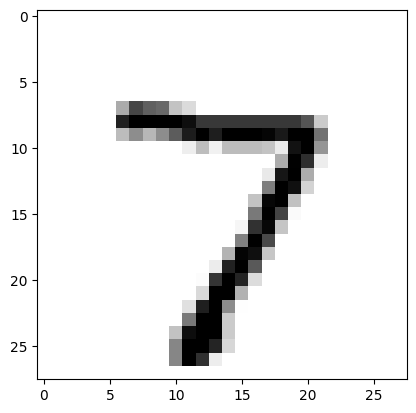

Predicted label: 7


In [7]:
# Predict on the first image in the test dataset
predictions = model.predict(test_images)

# Display the first test image and its predicted label
plt.imshow(test_images[0].reshape(28, 28), cmap=plt.cm.binary)
plt.show()

# Print the predicted class
predicted_label = predictions[0].argmax()  # Get the index of the highest predicted probability
print(f'Predicted label: {predicted_label}')


Experiment with Different Hyperparameters:
Change the number of layers:

In [8]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(28 * 28,)),
    Dense(64, activation='relu'),  # Add another hidden layer
    Dense(10, activation='softmax')
])


Adjust the learning rate:

In [9]:
from tensorflow.keras.optimizers import Adam

optimizer = Adam(learning_rate=0.001)  # Try different values for learning rate
model.compile(optimizer=optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


Change batch size:

In [10]:
model.fit(train_images, train_labels, epochs=5, batch_size=64, validation_data=(test_images, test_labels))  # Try different batch sizes


2026-06-17 16:10:15.140268: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 188160000 exceeds 10% of free system memory.


Epoch 1/5


  1/938 ━━━━━━━━━━━━━━━━━━━━ 1:57:39 8s/step - accuracy: 0.1406 - loss: 2.2793

  3/938 ━━━━━━━━━━━━━━━━━━━━ 28s 30ms/step - accuracy: 0.1441 - loss: 2.2604  

  4/938 ━━━━━━━━━━━━━━━━━━━━ 37s 40ms/step - accuracy: 0.1530 - loss: 2.2512

...

908/938 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9854 - loss: 0.0459

915/938 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9854 - loss: 0.0459

922/938 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9853 - loss: 0.0459

932/938 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9853 - loss: 0.0459

938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9847 - loss: 0.0484 - val_accuracy: 0.9729 - val_loss: 0.0871


Use different optimizers:

SGD

In [11]:
model.compile(optimizer='sgd', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


RMSprop

In [12]:
model.compile(optimizer='rmsprop', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


Visualize Training Metrics

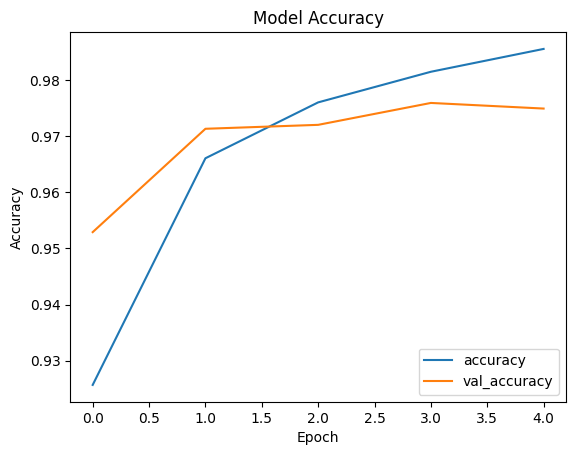

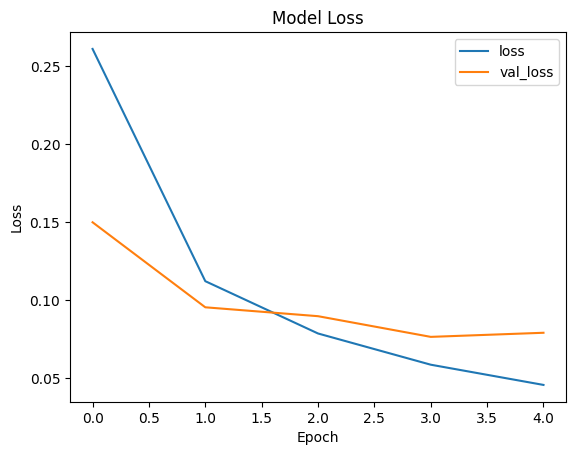

In [13]:
# Plot accuracy
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.title('Model Accuracy')
plt.show()

# Plot loss
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.title('Model Loss')
plt.show()


Try different numbers of layers and neurons: Adding more layers and neurons can sometimes help the model perform better, but be mindful of overfitting.

Experiment with batch sizes: Try different batch sizes (e.g., 16, 64, 128) and observe how they affect training time and performance.

Try different activation functions: You can experiment with activation functions like tanh, sigmoid, or elu instead of relu.

Adjust the optimizer and learning rate: The optimizer and learning rate can significantly impact the model’s performance.

